# Redes neuronales artificiales

## Inspiración biológica

### Neurona biológica

- Dendritas: Reciben señales de otras neuronas.
- Cuerpo Celular (Soma): Procesa las señales recibidas.
- Axón: Transmite la señal eléctrica a otras neuronas.
- Sinapsis: Conexiones entre neuronas donde se libera y recibe neurotransmisores.

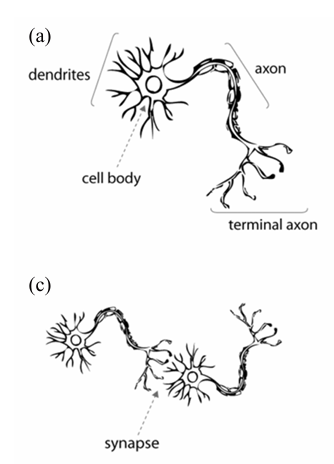


Fuente: Suzuki, K. (2013). Artificial neural networks: Architectures and applications.

### Neurona artificial

- Entradas (Inputs): Reciben datos o señales de otras neuronas (similares a las dendritas).
- Función de Activación: Procesa las señales recibidas (similar al cuerpo celular). Suma ponderada de las entradas seguida de una función de activación.
- Salida (Output): Transmite la señal procesada a otras neuronas (similar al axón).
- Pesos y Bias: Los pesos ajustan la importancia de cada entrada (similares a las sinapsis que modulan la fuerza de las señales).

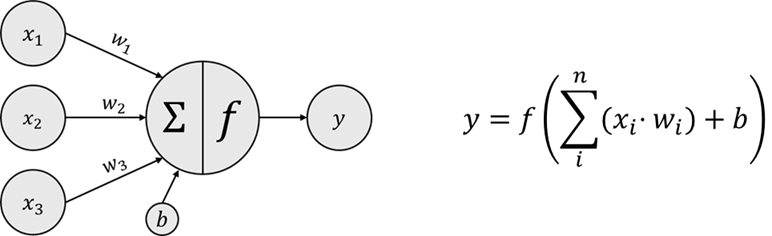

#### Funciones de activación

1. Lineal
\begin{align}
f(x) = x
\end{align}
\begin{align}
f'(x) = 1
\end{align}
\
Suelen usarse únicamente en la última capa en problemas de regresión. Si usamos solo funciones de activación lineales, la red devuelve simplemente una combinación lineal de los inputs.


2. Sigmoide
\begin{align}
f(x) = \frac{1}{1+e^{-x}}
\end{align}
\begin{align}
f'(x) = f(x)\cdot[1-f(x)]
\end{align}


3. Tangente hiperbólica
\begin{align}
f(x) = \frac{2}{1+e^{-2x}}-1
\end{align}
\begin{align}
f'(x) = 1 - f(x)^2
\end{align}


4. ReLU
\begin{align}
f(x) =
\begin{cases}
0 & \text{si } x<0\\
x & \text{si } x\geq0\\
\end{cases}
\end{align}

\begin{align}
f'(x) =
\begin{cases}
0 & \text{si } x<0\\
1 & \text{si } x\geq0\\
\end{cases}
\end{align}


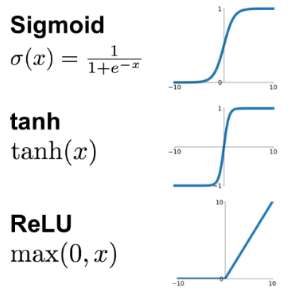

## Arquitectura de una red
* **Capa de entrada o  *input layer:*** Tiene tantas neuronas como variables predictoras.
* **Capas ocultas o *hidden layers:*** varía según la arquitectura que elijamos
* **Capa de salida o *output layer:*** Tiene tantas neuronas como variables queramos predecir. En el caso de clasificación, tantas neuronas como el número de clases.


<img src="https://www.researchgate.net/profile/Carolina-Meruane-2/publication/335505781/figure/fig1/AS:797759007379456@1567211977011/Scheme-of-an-Artificial-Neural-Network.png" width=600>

La figura muestra una arquitectura de red típica: *feedforward* con capas *fully connected*.

* *Feedforward:*  la información se mueve en una única dirección: adelante. De los nodos de entrada, a través de los nodos de las capas ocultas, hacia los nodos de salida. No hay ningún ciclo o bucle en estas redes.
* *Capa fully connected (o dense layer):* capa donde cada neurona está conectada con cada una de las neuronas de la capa anterior.

**Deep Learning** >> múltiples capas ocultas

## Entrenamiento

El entrenamiento en redes neuronales implica **ajustar los parámetros del modelo para optimizar una métrica específica**. Por ejemplo, en la regresión lineal, el objetivo del entrenamiento es encontrar los valores de los $w_i$ que minimicen el error cuadrático medio.

En redes neuronales, el proceso es similar: se ajustan los pesos y bias de cada capa para minimizar una función de costo. Las funciones de costo más comunes son el **error cuadrático medio** para tareas de regresión y la **entropía cruzada** para tareas de clasificación.

La principal diferencia con otros algoritmos que hemos visto es la **gran cantidad de parámetros** que hay que ajustar en una red neuronal. Esto hace que el proceso de entrenamiento sea más complejo y requiera técnicas específicas como backpropagation y el uso de optimizadores como el descenso de gradiente.

### Cálculo del número de parámetros

Por ejemplo, si queremos resolver el problema del TP2 (1C2024), donde tenemos **27 variables de entrada** y **7 clases objetivo**, y además decidimos tener **dos capas ocultas de 100 neuronas cada una**, el número de parámetros va a ser el siguiente:



(27 * 100 + 100) + (100 * 100 + 100) + (100 * 7 + 7) =  13607 parámetros

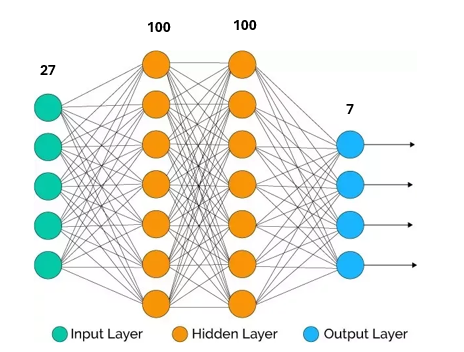

### Descenso del gradiente

#### Respaso del concepto de gradiente
Si $f: \mathbb{R}^n → \mathbb{R}$ es un campo escalar entonces el gradiente de $f$ en **$r$** se define como el campo vectorial $∇f:\mathbb{R}^n → \mathbb{R}^n$ cuyas componentes son las derivadas parciales del campo escalar, esto es:
\begin{align}
∇f(\textbf{r}) = \left(\frac{\partial f(\textbf{r})}{\partial z_1}, ... , \frac{\partial f(\textbf{r})}{\partial z_n}\right)
\end{align}

El gradiente en un punto $\textbf{r}$ indica la dirección de **máxima pendiente**.

Llevandolo a nuestro problema:
* $f: \mathbb{R}^n → \mathbb{R}$ es la función de costo a minimizar (por ej: error cuadrático medio)
* $n$: cantidad de parámetros a modificar (pesos y bias)
* El valor de $f$ va a depender de todas las muestras del conjunto de entrenamiento.
* Para un determinado conjunto de entrenamiento y un determinado conjunto de $n$ parámetros (vector $\textbf{r}$), tenemos un único valor de $f$.


#### Método del descenso del gradiente


El **descenso de gradiente** es un algoritmo de optimización genérico capaz de encontrar soluciones óptimas a una amplia variedad de problemas. La idea general del descenso de gradiente es **ajustar los parámetros de forma iterativa** para minimizar la función de costo.

En cada iteración, el algoritmo mide el **gradiente** local de la función de costo respecto al vector de parámetros **$r$** y va en la dirección del **gradiente descendente**. Para acercarse al mínimo de la función de costo, el algoritmo toma pasos pequeños en la dirección opuesta al gradiente (ya que el gradiente nos lleva hacia el máximo de la función).

<img src="https://miro.medium.com/v2/resize:fit:720/format:webp/1*mElyetzsTIJrNnKI8kTkCw.jpeg" width=600>

La cantidad de **ajuste** que se realiza en cada paso depende del **learning rate** (tasa de aprendizaje), un hiperparámetro que controla la magnitud de los pasos dados en la dirección del gradiente. Matemáticamente, en cada iteración, los parámetros **$r$**  se actualizan según la siguiente fórmula:

\begin{align}
\textbf{r}_{t+1} = \textbf{r}_t - \eta ∇f(\textbf{r})
\end{align}

Donde:
- $\textbf{r}_t$ es el valor de los parámetros en la iteración $t$,
- $∇f(\textbf{r})$ es el gradiente de la función de costo respecto a los parámetros $\textbf{r}$,
- $\eta$ es la **tasa de aprendizaje** o **learning rate**,
- $\textbf{r}_{t+1}$ es el valor actualizado de los parámetros.

La tasa de aprendizaje, $\eta$, controla **el tamaño de cada paso** en la dirección del gradiente. Si $\eta$ es muy grande, el algoritmo puede **sobresaltar el mínimo** y no converger a una solución óptima. Por otro lado, si $\eta$ es demasiado pequeño, el algoritmo **puede tardar mucho tiempo en converger** o quedar atascado en un mínimo local.

Una vez que el gradiente es cero, se ha encontrado un mínimo de la función de costo, aunque este puede ser un **mínimo local** o un **mínimo global**.



### Retropropagación (Backpropagation)

La retropropagación es un algoritmo utilizado para entrenar redes neuronales. Su objetivo es minimizar la función de costo ajustando los pesos y bias de la red. La retropropagación consta de dos fases principales: la fase de propagación hacia adelante y la fase de propagación hacia atrás.

* Propagación hacia adelante:

  * En esta fase, los datos de entrada se pasan a través de la red capa por capa.
  
  * Cada neurona realiza una operación matemática sobre los datos de entrada, aplicando sus pesos y bias, y luego pasa la salida a la siguiente capa.
  
  * Al final, la red produce una salida, que se compara con la salida esperada (etiqueta o valor real) para calcular el error mediante la función de costo.

* Propagación hacia atrás:

  * Acá es donde entra en juego la retropropagación. El objetivo es calcular el gradiente de la función de costo con respecto a cada peso y bias en la red.
  * El error calculado en la fase anterior se propaga de vuelta a través de la red, desde la capa de salida hasta la capa de entrada.
  * Para cada neurona, se calcula cómo contribuye al error total. Gracias a la **regla de la cadena**, es posible calcular de manera eficiente y exacta cómo cada peso y bias afecta al error total (derivadas parciales). De esta forma se obtiene el gradiente de la función de costo para el conjunto de parámetros actual.
  * El descenso del gradiente se usa para ajustar los pesos y bias de la red en función de estos gradientes, reduciendo así el error en la próxima iteración.


* Resumen del proceso:

  1. **Inicialización**: Los pesos y bias se inicializan de manera aleatoria.
  2. **Propagación hacia adelante**: Se pasa la entrada a través de la red para obtener una predicción.
  3. **Cálculo del error**: Se compara la predicción con la salida esperada usando la función de costo.
  4. **Propagación hacia atrás**: Se calcula el gradiente del error con respecto a cada peso y bias.
  5. **Actualización de parámetros**: Se ajustan los pesos y bias usando el descenso del gradiente.
  6. **Repetición**: Se repiten los pasos 2 a 5 para un número determinado de iteraciones o hasta que el error sea suficientemente pequeño.

La retropropagación es un proceso iterativo que requiere múltiples pasos hacia adelante y hacia atrás a través de la red hasta que los pesos y bias estén optimizados para minimizar el error de predicción.

### Optimización del método del descenso del gradiente

El método del descenso de gradiente puede ser muy costoso computacionalmente. Esto se debe a que calcular el gradiente en cada iteración implica evaluar la derivada parcial respecto a cada uno de los parámetros para todas las muestras del conjunto de datos. Por ejemplo, si la función de costo es el error cuadrático medio (ECM) y tenemos una única variable de salida $y$, la derivada parcial respecto a un parámetro $w_i$ sería:

\begin{align}
\frac{∂ ECM}{∂ w_i} = \frac{∂ ∑_{j=1}^m \frac{1}{m} (y_j - \hat{y}_j)^2}{∂ w_i} =\frac{1}{m}[2(y_1 - \hat{y}_1)\cdot \frac{\partial \hat{y}_1}{\partial w_i} + ... + 2(y_m - \hat{y}_m)\cdot \frac{\partial \hat{y}_m}{\partial w_i}]
\end{align}


Donde $m$ es el número de muestras en el conjunto de entrenamiento.


El cálculo de cada derivada parcial $\frac{\partial \hat{y}_j}{\partial w_i}$ implica aplicar la regla de la cadena a través de toda la red.




Es por eso que existen otras variantes de este método, más eficientes desde el punto de vista computacional:
1. **Descenso de gradiente estocástico (SGD)**

En lugar de utilizar todo el conjunto de datos, SGD actualiza los parámetros usando un solo ejemplo de entrenamiento a la vez.
Es más rápido y consume menos memoria que el descenso de gradiente tradicional, pero es más inestable (las actualizaciones pueden oscilar alrededor del mínimo en lugar de converger suavemente).

2. **Descenso de gradiente por minilotes *(minibatchs)***

En cada paso, en vez de calcular los gradientes en el conjunto de
entrenamiento completo (como en el descenso de gradiente por lotes) o basándonos en solo una instancia (como en el descenso de gradiente estocástico), el descenso de gradiente por minilotes calcula los gradientes en conjuntos aleatorios pequeños de instancias llamados minilotes.
Proporciona un equilibrio entre la eficiencia computacional y la estabilidad de la convergencia.

Se utilizan los siguientes términos:
* **Épocas:** cantidad de veces que se recorre el dataset
completo.
* **Iteraciones:** cantidad de veces que se actualizan los
parámetros (pesos) de la red (una iteración por lote)

**Ejemplo 1:** Si nuestro conjunto de entrenamiento tiene 1000 muestras, y el tamaño del lote es de 50 muestras, vamos a tener 20 iteraciones por época.

**Ejemplo 2**: Si trabajamos con lotes de 100 muestras y nuestro conjunto de entrenamiento tiene 500 muestras. Después de 30 iteraciones vamos haber completado 6 épocas.





<img src="https://statusneo.com/wp-content/uploads/2023/09/Credit-Analytics-Vidya.jpg" width=600>

Estas técnicas, además de mejorar la eficiencia computacional, a diferencia del descenso de gradiente tradicional, permiten "escaparnos" de los mínimos locales, ya que la función de costo en cada iteración cambia.

## Otros tipos de arquitecturas


### Redes Convolucionales (CNNs)

Las Redes Neuronales Convolucionales (CNNs) están diseñadas para procesar datos con una estructura en forma de grilla, como imágenes. Utilizan capas convolucionales que aplican filtros (o kernels) para extraer características locales de las imágenes, como bordes, texturas y patrones.

Aplicaciones:

* Reconocimiento de imágenes: Clasificación de imágenes en categorías (p.ej., identificar objetos en fotos).
* Detección de objetos: Localizar y clasificar múltiples objetos dentro de una imagen.
* Reconocimiento de Texto en Imágenes: OCR (reconocimiento óptico de caracteres).

### Redes Recurrentes (RNNs)

Las Redes Neuronales Recurrentes (RNNs) están diseñadas para procesar datos secuenciales, donde la información temporal o de orden es crucial. En este tipo de redes, la salida de una neurona en un paso de tiempo se usa como entrada para la misma o diferentes neuronas en el siguiente paso de tiempo. Esto les permite mantener una memoria de estados anteriores.

Aplicaciones:

* Procesamiento de Lenguaje Natural (NLP): Traducción automática, generación de texto, análisis de sentimientos.
* Series temporales: Predicción de valores futuros basados en datos históricos (p.ej., precios de acciones).
* Reconocimiento de voz: Convertir audio de voz en texto.

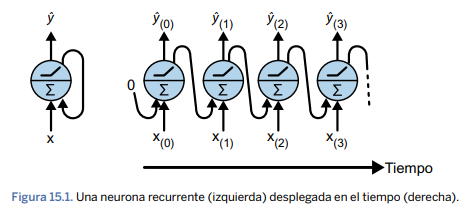

Fuente: Géron, A. (2020). Aprende machine learning con scikit-learn, keras y tensorflow. España: Anaya.

### Redes Generativas antagónicas (GANs)

Las Redes Generativas Antagónicas (GANs) constan de dos redes neuronales que compiten entre sí: un generador y un discriminador. El generador crea datos falsos (p.ej., imágenes) intentando imitar los datos reales, mientras que el discriminador intenta distinguir entre los datos reales y los falsos.

Aplicaciones:

* Generación de imágenes: Crear imágenes sintéticas que parecen reales (por ej., rostros humanos: https://thispersondoesnotexist.com/).
* Superresolución de imágenes: Mejorar la resolución de imágenes de baja calidad.
* Generación de Contenido: Crear arte, música, y otros tipos de contenido creativo.

\\

<img src="https://ars.els-cdn.com/content/image/1-s2.0-S009784932300064X-ga1_lrg.jpg" width=900>

Fuente: De Souza, V. L. T., Marques, B. A. D., Batagelo, H. C., & Gois, J. P. (2023). A review on generative adversarial networks for image generation. Computers & Graphics, 114, 13-25. https://doi.org/10.1016/j.cag.2023.05.010

### Transformers
Las redes neuronales tipo Transformer son un tipo de arquitectura de diseñada para procesar secuencias de datos. Se basan en un mecanismo llamado atención que permite al modelo enfocarse en diferentes partes de la secuencia al mismo tiempo, sin necesidad de procesarlas en orden.

Esta arquitectura es altamente paralelizable, lo que la hace eficiente para entrenar con grandes volúmenes de datos.

Algunas aplicaciones:

* Modelos de lenguaje (LLM): utilizados para generación de texto, traducción automática, respuesta a preguntas, etc. Ejemplo: chatGPT.

* Visión por computadora

* Multimodalidad: modelos que combinan texto e imagen como DALL·E

* Bioinformática: predicción de estructuras de proteínas a partir de secuencias (AlphaFold).

## Ventajas y desventajas

**Ventajas de las Redes Neuronales**

* Capacidad de Aprendizaje:

Las redes neuronales pueden aprender patrones complejos y no lineales en los datos, lo que las hace muy versátiles para diversas tareas.

* Autonomía en la Extracción de Atributos:

A diferencia de los métodos tradicionales de machine learning que requieren ingeniería manual de atributos, las redes neuronales pueden aprender automáticamente los atributos más relevantes directamente a partir de los datos.

* Aplicabilidad a Diversas Áreas:

Se utilizan en una amplia gama de aplicaciones, incluyendo reconocimiento de imágenes, procesamiento de lenguaje natural, reconocimiento de voz, generación de texto e imágenes, entre otros.

* Mejora con Más Datos:

Las redes neuronales tienden a mejorar su rendimiento a medida que se incrementa la cantidad de datos disponibles para el entrenamiento.


**Desventajas de las Redes Neuronales**

* Requieren Grandes Cantidades de Datos:

Para entrenar redes neuronales profundas efectivamente, se necesita una gran cantidad de datos etiquetados, lo que puede no estar disponible en todas las situaciones.

* Alto Costo Computacional:

El entrenamiento de redes neuronales, especialmente redes profundas, requiere una gran cantidad de poder computacional y tiempo. Esto puede ser costoso y lento sin acceso a hardware especializado como GPUs o TPUs.

* Complejidad en la Interpretación:

Las redes neuronales a menudo son consideradas "cajas negras" debido a la dificultad de interpretar y entender cómo toman decisiones. Esto puede ser un problema en aplicaciones donde la interpretabilidad es crucial.

* Riesgo de Sobreajuste:

Si no se implementan correctamente las técnicas de regularización, las redes neuronales pueden sobreajustar los datos de entrenamiento, lo que resulta en un mal desempeño en datos nuevos.

* Sensibilidad a los Hiperparámetros:

El rendimiento de las redes neuronales depende en gran medida de la configuración de los hiperparámetros (como el número de capas, el número de neuronas por capa, etc.). Encontrar la combinación óptima puede ser un proceso complejo y laborioso.


## Implementación

Las librerías más utilizadas son:
* scikit learn
* tensorflow + keras
* pytorch

## Ejemplo

Dimensiones X_train: (60000, 28, 28)
Dimensiones X_test: (10000, 28, 28)
Dimensiones y_train: (60000, 10)
Dimensiones y_test: (10000, 10)


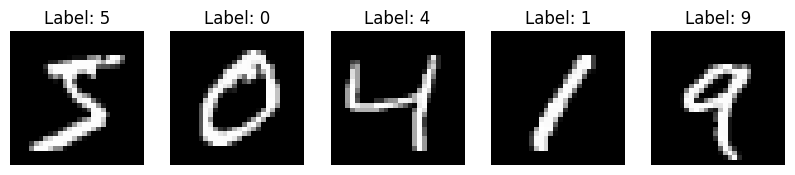

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Cargar y preprocesar los datos
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train / 255.0   # para llevar al rango [0, 1]
x_test = x_test / 255.0     # para llevar al rango [0, 1]

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print(f'Dimensiones X_train: {x_train.shape}')
print(f'Dimensiones X_test: {x_test.shape}')
print(f'Dimensiones y_train: {y_train.shape}')
print(f'Dimensiones y_test: {y_test.shape}')

# Visualizar algunas imágenes del conjunto de datos MNIST
def plot_mnist_samples(images, labels, num_samples=5):
    plt.figure(figsize=(10, 2))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f'Label: {labels[i]}')
        plt.axis('off')
    plt.show()

# Mostrar 5 imágenes del conjunto de entrenamiento
plot_mnist_samples(x_train, y_train.argmax(axis=1), num_samples=5)


In [4]:
# Construir el modelo secuencial
model = Sequential([
    Flatten(input_shape=(28, 28)),  # Aplanar las imágenes 28x28 en un vector de 784 elementos
    Dense(128, activation='relu'),  # Capa densa con 128 neuronas y función de activación ReLU
    Dense(10, activation='softmax')  # Capa de salida con 10 neuronas (una por clase) y función de activación softmax
])

# Compilar el modelo
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entrenar el modelo
model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluar el modelo
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'\nTest accuracy: {test_acc}')


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8718 - loss: 0.4579 - val_accuracy: 0.9552 - val_loss: 0.1578
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9605 - loss: 0.1394 - val_accuracy: 0.9627 - val_loss: 0.1232
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9745 - loss: 0.0883 - val_accuracy: 0.9670 - val_loss: 0.1092
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9806 - loss: 0.0642 - val_accuracy: 0.9701 - val_loss: 0.0981
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9865 - loss: 0.0467 - val_accuracy: 0.9717 - val_loss: 0.0994
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9884 - loss: 0.0385 - val_accuracy: 0.9733 - val_loss: 0.0929
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9917 - loss: 0.0285 - val_accuracy: 0.9697 - val_loss: 0.1053
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9935 - loss: 0.0228 - 